# NIF Laser sampling

<a href="[text](https://creativecommons.org/licenses/by-nc/4.0/)">LaserIllumination</a> © 2025 by <a href="https://creativecommons.org">M. Cotelo, A. Lorca (Universidad Politécnica de Madrid)</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/sa.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">


Authors:
- Manuel Cotelo Ferreiro (<manuel.cotelo@upm.es>) (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid)
- Alberto Lorca (<alberto.lorca@alumnos.upm.es>) (Universidad Politécnica de Madrid)

In [1]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
 #!pip install trame
from scipy.stats import norm
import scipy.stats as stats



## Support functions

### Sphere parameters

In [2]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / r)
    phi = np.pi + np.arctan2(y, x)
    return np.array([r, theta, phi])

In [3]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [4]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):

  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter


## Sample of random laser points in a 2D window

In [5]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  # sample distribution 
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [6]:

t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


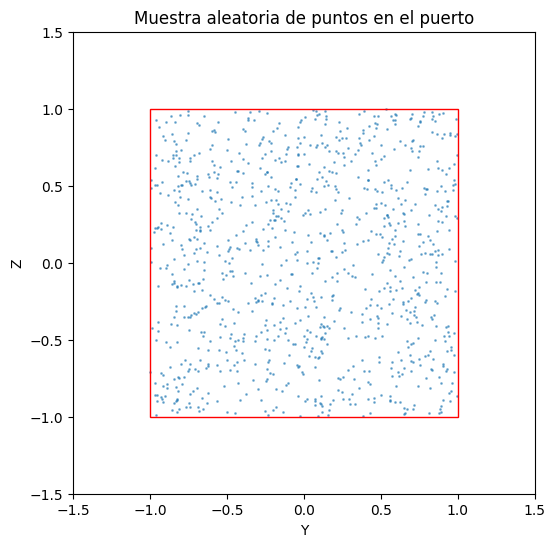

In [7]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points

In [8]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


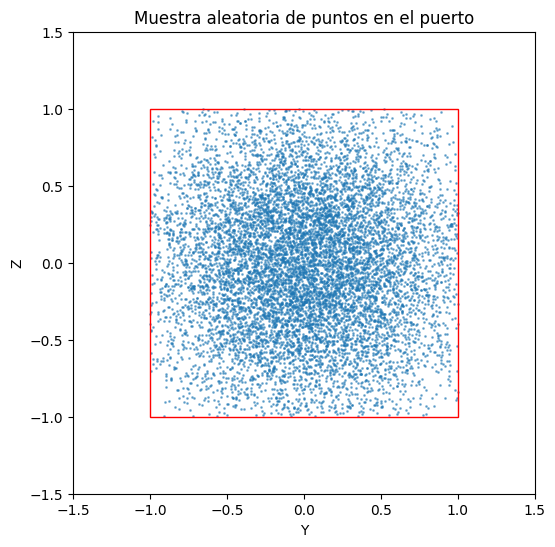

In [9]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

## Beams geometry and dataframe

In [10]:
def beam():

    # ============================
    # 1. Crear puertos (sin foco)
    # ============================
    def create_ports(theta, num, long_ref, root, color, energy, wavelength):
        list_long = long_ref + np.linspace(0., 2.*np.pi, num, endpoint=False)
        return [{
            'name': f'{root}J{i+1}',
            'LAT': theta,
            'LONG': long,
            'color': color,
            'foco': None,          # <-- Se asignará después
            'energia': energy,
            'longonda': wavelength,
        } for i, long in enumerate(list_long)]

    ports = []
    ports += create_ports(np.deg2rad(23.5), 4, 0.,        'NP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.deg2rad(30.0), 4, np.pi/4.,  'NP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.deg2rad(44.5), 8, np.pi/16., 'NP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.deg2rad(50.0), 8, 3*np.pi/16., 'NP4', 'purple', 1.0, 351e-6)

    ports += create_ports(np.pi - np.deg2rad(23.5), 4, 0.,        'SP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(30.0), 4, np.pi/4.,  'SP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(44.5), 8, np.pi/16., 'SP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(50.0), 8, 3*np.pi/16., 'SP4', 'purple', 1.0, 351e-6)

    ports_df = pd.DataFrame(ports)

    # =====================================================
    # 2. Calcular normales, tangentes y subventanas
    # =====================================================
    def compute_tangents_and_subwindows(row):
        R = 5.0  # radio de la cámara
        normal = sph_to_cart(R, row['LAT'], row['LONG'])
        normal = normal / np.linalg.norm(normal) * R

        # Ejes tangenciales
        t2 = np.array([0.0, 1.0, 0.0])
        t1 = np.cross(t2, normal)
        t1 /= np.linalg.norm(t1)

        ports_size = 0.80
        lx = ly = ports_size / 2.0

        offsets = [
            (+lx/2, +ly/2),
            (-lx/2, +ly/2),
            (+lx/2, -ly/2),
            (-lx/2, -ly/2)
        ]

        centers = [normal + dx * t1 + dy * t2 for dx, dy in offsets]

        return pd.Series({
            'normal': normal,
            't1': t1,
            't2': t2,
            'lx': lx,
            'ly': ly,
            'windows': centers
        })

    ports_df = pd.concat([ports_df, ports_df.apply(compute_tangents_and_subwindows, axis=1)], axis=1)

    # =====================================================
    # 3. Asignar foco real según anillo (datos del paper)
    # =====================================================
    focal_map = {
        "NP1": 8.0,  "SP1": 8.0,
        "NP2": 8.8,  "SP2": 8.8,
        "NP3": 10.0, "SP3": 10.0,
        "NP4": 12.0, "SP4": 12.0,
    }

    def compute_focus(normal, f_distance):
        # El foco está f metros hacia dentro del blanco
        return -normal / np.linalg.norm(normal) * f_distance

    def assign_real_focus(row):
        ring = row["name"][:3]
        f_dist = focal_map[ring]
        return compute_focus(row["normal"], f_dist)

    ports_df["foco"] = ports_df.apply(assign_real_focus, axis=1)

    # =====================================================
    # 4. Construir lista final de subventanas (beams)
    # =====================================================
    beam_list = []
    for _, row in ports_df.iterrows():
        for i, center in enumerate(row['windows']):
            beam_list.append({
                'port': row['name'],
                'subwindow': i,
                'LAT': row['LAT'],
                'LONG': row['LONG'],
                'color': row['color'],
                'focus': row['foco'],
                'energy': row['energia'],
                'wavelength': row['longonda'],
                'center': center,
                't1': row['t1'],
                't2': row['t2'],
                'l1': row['lx'],
                'l2': row['ly'],
                'normal': row['normal']
            })

    return beam_list


In [11]:
## Descompone los caracteres vectoriales en columnas individuales
def expand_vector_columns_xyz(df, vector_columns):
    coord_labels = ['x', 'y', 'z']
    for col in vector_columns:
        if col in df.columns:
            expanded = pd.DataFrame(df[col].tolist(), columns=[f"{col}_{axis}" for axis in coord_labels], index=df.index)
            df = pd.concat([df.drop(columns=[col]), expanded], axis=1)
    return df


beam_list = beam()
beam_df = pd.DataFrame(beam_list)

# Descomponer columnas vectoriales en x, y, z solo para visualización
vector_cols = ['center', 't1', 't2', 'normal', 'focus']
beam_df_vista = expand_vector_columns_xyz(beam_df.copy(), vector_cols)

# Mostrar resultado
beam_df_vista

,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,NP1J1,0,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,-3.987491e-01,0.0,1.0,0.0,1.993745e+00,0.000000,4.585300,-3.189993e+00,-0.000000,-7.336481
1,NP1J1,1,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,-3.987491e-01,0.0,1.0,0.0,1.993745e+00,0.000000,4.585300,-3.189993e+00,-0.000000,-7.336481
2,NP1J1,2,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,-3.987491e-01,0.0,1.0,0.0,1.993745e+00,0.000000,4.585300,-3.189993e+00,-0.000000,-7.336481
3,NP1J1,3,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,-3.987491e-01,0.0,1.0,0.0,1.993745e+00,0.000000,4.585300,-3.189993e+00,-0.000000,-7.336481
4,NP1J2,0,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,0.200000,...,-2.662458e-17,0.0,1.0,0.0,1.220817e-16,1.993745,4.585300,-1.953307e-16,-3.189993,-7.336481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,SP4J7,3,2.268928,5.301438,purple,1.0,0.000351,0.4,0.4,2.294718,...,-5.520629e-01,0.0,1.0,0.0,2.127957e+00,-3.184713,-3.213938,-5.107098e+00,7.643312,7.713451
188,SP4J8,0,2.268928,6.086836,purple,1.0,0.000351,0.4,0.4,3.626608,...,-7.598586e-01,0.0,1.0,0.0,3.756626e+00,-0.747239,-3.213938,-9.015901e+00,1.793374,7.713451
189,SP4J8,1,2.268928,6.086836,purple,1.0,0.000351,0.4,0.4,3.886643,...,-7.598586e-01,0.0,1.0,0.0,3.756626e+00,-0.747239,-3.213938,-9.015901e+00,1.793374,7.713451
190,SP4J8,2,2.268928,6.086836,purple,1.0,0.000351,0.4,0.4,3.626608,...,-7.598586e-01,0.0,1.0,0.0,3.756626e+00,-0.747239,-3.213938,-9.015901e+00,1.793374,7.713451


## Impacts of the laser beams from window to a target sphere

### Hits on sphere

In [12]:

def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
  
  dx = x - center

  # Coeficientes de la ecuación cuadrática
  A = u[0]**2 + u[1]**2 + u[2]**2 
  B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
  C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

  disc = B*B - 4*A*C

  # Calcular puntos de intersección (si existen)
  if disc < 0:
    return []
  elif disc == 0:
    return [ -0.5 * B / A ] 
  else:
    disc = np.sqrt(disc)
    l1 = 0.5 * (-B + disc) / A
    l2 = 0.5 * (-B - disc) / A
    return [ l1, l2, ]


### Impact information

In [13]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):

  ls = hit_sphere( x, u, radius=radius, center=center, )
  
  if len(ls) == 0:
    return -1.
  elif len(ls) == 1:
    if ls[0] < 0:
      return -1.
    else:
      return ls[0]
  else:
    l1, l2 = ls
    if l1 < 0 and l2 < 0:
      return -1.
    elif l1 > 0 and l2 > 0:
      return min(l1, l2)
    else:
      return max(l1, l2)
    

  
def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
  l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Longitud de impacto
  xsph = x + l * u 
  n = ( xsph - center ) / np.linalg.norm( xsph - center )
  cs = np.dot( n, u) / np.linalg.norm(u)
  return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ] # Devuelve r, theta, phi del punto


### Validation of hits on sphere

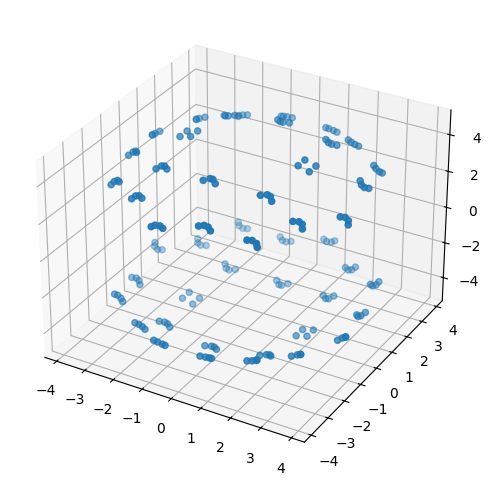

In [14]:
hits = []

for i, row in beam_df.iterrows():
    x = row["center"]
    focus = row["focus"]
    u = focus - x
    u = u / np.linalg.norm(u)

    hit = ray_hit(x, u, radius=5.0)
    xsph = hit[3]
    hits.append(xsph)

hits = np.array(hits)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(hits[:,0], hits[:,1], hits[:,2], s=20)
plt.show()


## Simulation of impacts with real geometry

In [15]:
def beam_sample( beam, num_samples ):
  t1 = beam['t1']
  t2 = beam['t2']
  l1 = beam['l1']
  l2 = beam['l2']
  center = beam['center']
  dist = beam.get( 'dist', lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), )
  return sample_window( t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist, )

In [16]:
def beam_hit(beam, num_samples, radius, center=np.array([0.0, 0.0, 0.0])):
    xs = beam_sample(beam, num_samples)
    us = beam['focus'] - xs
    us = us / np.linalg.norm(us, axis=1)[:, None]

    data = [ray_hit(xi, ui, radius=radius, center=center) for xi, ui in zip(xs, us)]
    df = pd.DataFrame(data, columns=['x', 'u', 'l', 'xsph', 'cs', 'sph', 'n'])

    # Añadir etiqueta de subventana
    df['subwindow'] = f"{beam['port']}_{beam['subwindow']}"

    return df

In [17]:
impact_df = beam_hit(beam_df.iloc[0], num_samples=1000000, radius=0.005, center=np.array([0.0, 0.0, 0.0]))

### Information of real impact

In [18]:
def impact_df_vista(df):
    df = expand_vector_columns_xyz(df, ['x', 'u', 'xsph', 'sph', 'n'])
    df[['r', 'theta', 'phi']] = df.apply(
        lambda row: pd.Series(cart_to_sph(row['xsph_x'], row['xsph_y'], row['xsph_z'])),
        axis=1
    )
    return df



In [19]:
impact_df = impact_df[impact_df["l"] > 0].reset_index(drop=True) ## Filtrar solo impactos válidos (l > 0) y resetear índice
impact_df= impact_df_vista(impact_df)
impact_df

,l,cs,subwindow,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,...,xsph_z,sph_x,sph_y,sph_z,n_x,n_y,n_z,r,theta,phi
0,4.996524,-0.695599,NP1J1_0,1.997672,0.003968,4.583593,-0.399051,-0.000305,-0.916929,0.003803,...,0.002137,0.005,1.129178,3.712505,0.760685,0.488555,0.427403,0.005,1.129178,3.712505
1,4.996705,-0.659540,NP1J1_0,1.999194,0.001412,4.582931,-0.399168,-0.000109,-0.916878,0.004669,...,0.001564,0.005,1.252673,3.325641,0.933782,0.173828,0.312785,0.005,1.252673,3.325641
2,4.996889,-0.622775,NP1J1_0,1.998844,0.003082,4.583083,-0.399141,-0.000237,-0.916889,0.004380,...,0.001489,0.005,1.268413,3.550366,0.875977,0.379450,0.297796,0.005,1.268413,3.550366
3,4.996139,-0.772593,NP1J1_0,1.997341,0.003353,4.583737,-0.399026,-0.000258,-0.916940,0.003753,...,0.002579,0.005,1.028877,3.644380,0.750695,0.412828,0.515781,0.005,1.028877,3.644380
4,4.995141,-0.971804,NP1J1_0,1.993898,0.001909,4.585234,-0.398761,-0.000147,-0.917055,0.002031,...,0.004415,0.005,0.488571,3.666076,0.406274,0.235042,0.883004,0.005,0.488571,3.666076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,4.997205,-0.559556,NP1J1_0,1.994254,0.006711,4.585079,-0.398788,-0.000516,-0.917043,0.001428,...,0.002428,0.005,1.063841,4.379604,0.285589,0.826264,0.485517,0.005,1.063841,4.379604
320,4.997863,-0.428078,NP1J1_0,1.999541,0.003738,4.582780,-0.399195,-0.000288,-0.916866,0.004420,...,0.000409,0.005,1.488860,3.621542,0.884042,0.460185,0.081845,0.005,1.488860,3.621542
321,4.999133,-0.174240,NP1J1_0,2.000774,0.002295,4.582244,-0.399290,-0.000177,-0.916825,0.004672,...,-0.001085,0.005,1.789496,3.435141,0.934422,0.282458,-0.216961,0.005,1.789496,3.435141
322,4.996517,-0.696979,NP1J1_0,1.999005,0.001028,4.583014,-0.399154,-0.000079,-0.916884,0.004627,...,0.001787,0.005,1.205419,3.277557,0.925369,0.126598,0.357301,0.005,1.205419,3.277557


### Plots the impacts of one subwindow in the sphere

In [20]:
def plot_impacts_on_sphere(impact_df, beam, sphere_radius=0.005):
    # Filtrar impactos válidos
    valid = impact_df[impact_df["l"] > 0].copy()

    if valid.empty:
        print("⚠ No hay impactos válidos para este haz.")
        return

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Dibujar esfera del blanco
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere,
                    color='lightblue', alpha=0.3, linewidth=0)

    # Dibujar impactos válidos
    xsph = valid[['xsph_x', 'xsph_y', 'xsph_z']].values
    ax.scatter(xsph[:, 0], xsph[:, 1], xsph[:, 2],
               color='red', s=10, label='Impactos válidos')

    ax.set_title(f"Impactos del haz {beam['port']}_{beam['subwindow']}")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.set_box_aspect([1, 1, 1])
    plt.show()


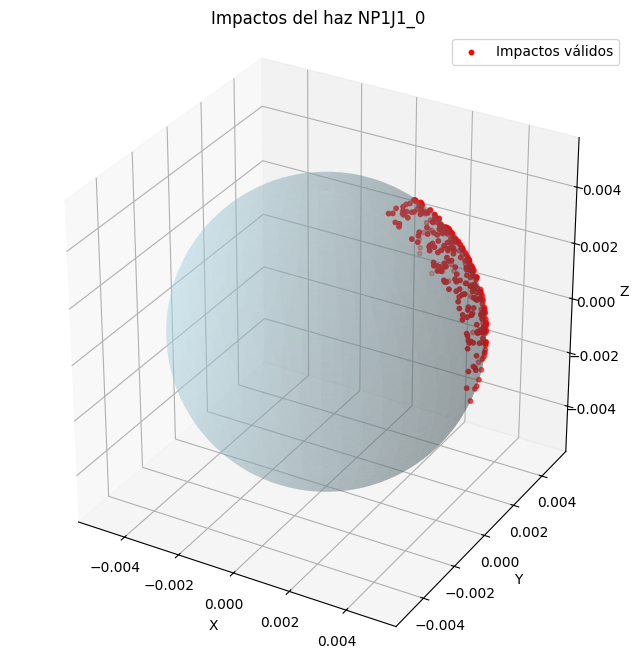

In [21]:
plot_impacts_on_sphere(impact_df, beam_df.iloc[0])


### Pyvista plotter of the impacts in one subwindow

In [22]:
def plot_impacts_pyvista(impact_df, sphere_radius=0.005):
    # ============================
    # 1. Filtrar impactos válidos
    # ============================
    valid = impact_df[impact_df["l"] > 0].copy()

    if valid.empty:
        print("⚠ No hay impactos válidos sobre el blanco.")
        return

    # ============================
    # 2. Extraer puntos de impacto
    # ============================
    xsph_array = valid[['xsph_x', 'xsph_y', 'xsph_z']].values
    ls_array = valid['l'].values

    # ============================
    # 3. Crear nube de puntos
    # ============================
    point_cloud = pv.PolyData(xsph_array)
    point_cloud["Distancia del rayo (l)"] = ls_array

    # ============================
    # 4. Crear esfera del blanco
    # ============================
    sphere = pv.Sphere(radius=sphere_radius, center=(0, 0, 0))

    # ============================
    # 5. Visualización
    # ============================
    plotter = pv.Plotter()
    plotter.add_mesh(sphere, color="lightblue", opacity=0.3)

    plotter.add_points(
        point_cloud,
        scalars="Distancia del rayo (l)",
        render_points_as_spheres=True,
        point_size=12,
        cmap="viridis"
    )

    plotter.show()

In [23]:
plot_impacts_pyvista(impact_df)


Widget(value='<iframe src="http://localhost:55775/index.html?ui=P_0x188a2508490_0&reconnect=auto" class="pyvis…

## Simulation of hits from windows chosen by probability

### Impact simulation

In [24]:
def simular_impactos(
    num_beams_to_sample,
    num_samples_per_beam,
    target_radius,
    target_center
 ):
    # 1. Generar todos los haces
    beam_df = pd.DataFrame(beam())

    # 2. Probabilidades según energía
    ps = np.array(beam_df['energy'], dtype=float)
    ps /= np.sum(ps)

    # 3. Selección aleatoria de haces
    list_beams = np.arange(len(beam_df))
    selected_indices = np.random.choice(
        list_beams,
        size=num_beams_to_sample,
        p=ps
    )

    # 4. Simulación de impactos
    impact_df = pd.concat([
        beam_hit(
            beam_df.iloc[i],
            num_samples_per_beam,
            radius=target_radius,
            center=target_center
        ).assign(
            port=beam_df.iloc[i]['port'],
            subwindow=beam_df.iloc[i]['subwindow']
        )
        for i in selected_indices
    ], ignore_index=True)

    # 5. Filtrar impactos válidos
    impact_df = impact_df[impact_df["l"] > 0].copy()

    return impact_df


### Information of impacts in dataframe

In [25]:
def preparar_dataframe_impactos(impact_df):
    # 1. Expandir vectores y añadir coordenadas esféricas
    impact_df = impact_df_vista(impact_df)

    # 2. Asegurar columnas port y subwindow
    if 'port' not in impact_df.columns:
        impact_df['port'] = 'desconocido'
    if 'subwindow' not in impact_df.columns:
        impact_df['subwindow'] = 'desconocido'

    # 3. Seleccionar columnas relevantes
    cols = [
        'port', 'subwindow', 'l', 'cs', 'theta', 'phi',
        'x_x', 'x_y', 'x_z',
        'u_x', 'u_y', 'u_z',
        'xsph_x', 'xsph_y', 'xsph_z',
        'n_x', 'n_y', 'n_z'
    ]
    available_cols = [c for c in cols if c in impact_df.columns]

    # 4. Redondear y devolver DataFrame final
    formatted_df = impact_df[available_cols].round(4)

    print(f"Impactos válidos encontrados: {len(formatted_df)}")
    return formatted_df


### Pyvista plot

In [31]:
def plot_impactos_pyvista(impact_df, sphere_radius=0.005):
    
    # ============================
    # 1. Filtrar impactos válidos
    # ============================
    valid = impact_df[impact_df["l"] > 0].copy()

    if valid.empty:
        print("⚠ No hay impactos válidos para visualizar.")
        return

    # ============================
    # 2. Extraer puntos y escalares
    # ============================
    xsph_array = valid[['xsph_x', 'xsph_y', 'xsph_z']].values
    ls_array = valid['l'].values

    # Crear nube de puntos
    point_cloud = pv.PolyData(xsph_array)
    point_cloud["Distancia del rayo (l)"] = ls_array

    # ============================
    # 3. Crear esfera del blanco
    # ============================
    sphere = pv.Sphere(radius=sphere_radius, center=(0, 0, 0))

    # ============================
    # 4. Visualización
    # ============================
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter()

    # Esfera
    plotter.add_mesh(sphere, color="lightblue", opacity=0.3)

    # Impactos
    plotter.add_points(
        point_cloud,
        scalars="Distancia del rayo (l)",
        render_points_as_spheres=True,
        point_size=10,
        cmap="viridis"
    )

    plotter.show()


In [ ]:
impactos = simular_impactos(
    num_beams_to_sample=192,
    num_samples_per_beam=100000,
    target_radius=0.005,
    target_center=np.array([0.0, 0.0, 0.0])
)


Impactos válidos encontrados: 6142


Widget(value='<iframe src="http://localhost:55775/index.html?ui=P_0x18a7a63a2d0_1&reconnect=auto" class="pyvis…

In [32]:
df_impactos = preparar_dataframe_impactos(impactos)

plot_impactos_pyvista(df_impactos, sphere_radius=0.005)


Impactos válidos encontrados: 6142


Widget(value='<iframe src="http://localhost:55775/index.html?ui=P_0x18c19542cd0_3&reconnect=auto" class="pyvis…

In [28]:
df_impactos.head(10)

,port,subwindow,l,cs,theta,phi,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
3839,SP3J6,2,4.9982,-0.6804,1.5801,0.7013,-1.9514,-2.9167,-3.5639,0.3897,0.5829,0.7130,-0.0038,-0.0032,-0.0000,-0.7640,-0.6452,-0.0093
4418,SP3J6,2,4.9982,-0.5802,1.5008,0.5322,-1.9522,-2.9158,-3.5634,0.3897,0.5829,0.7130,-0.0043,-0.0025,0.0003,-0.8596,-0.5062,0.0699
4895,SP3J6,2,4.9969,-0.9215,1.9660,0.9652,-1.9488,-2.9164,-3.5653,0.3895,0.5829,0.7131,-0.0026,-0.0038,-0.0019,-0.5253,-0.7588,-0.3850
17279,SP3J6,2,4.9990,-0.7733,1.6867,1.1085,-1.9492,-2.9189,-3.5651,0.3895,0.5830,0.7130,-0.0022,-0.0044,-0.0006,-0.4430,-0.8890,-0.1157
19897,SP3J6,2,4.9998,-0.1002,1.1228,0.1145,-1.9536,-2.9144,-3.5627,0.3898,0.5828,0.7130,-0.0045,-0.0005,0.0022,-0.8954,-0.1029,0.4332
23075,SP3J6,2,5.0000,-0.5460,1.3811,0.8276,-1.9515,-2.9185,-3.5638,0.3896,0.5830,0.7130,-0.0033,-0.0036,0.0009,-0.6645,-0.7231,0.1886
24504,SP3J6,2,4.9984,-0.7531,1.6538,0.8649,-1.9505,-2.9176,-3.5644,0.3896,0.5829,0.7130,-0.0032,-0.0038,-0.0004,-0.6465,-0.7584,-0.0829
38758,SP3J6,2,5.0003,-0.5929,1.4291,1.0213,-1.9505,-2.9196,-3.5644,0.3895,0.5830,0.7130,-0.0026,-0.0042,0.0007,-0.5170,-0.8443,0.1412
40202,SP3J6,2,5.0019,-0.5299,1.4594,1.4890,-1.9478,-2.9217,-3.5658,0.3893,0.5831,0.7130,-0.0004,-0.0050,0.0006,-0.0811,-0.9905,0.1112
41174,SP3J6,2,4.9992,-0.2349,1.2325,0.2040,-1.9534,-2.9145,-3.5628,0.3898,0.5828,0.7130,-0.0046,-0.0010,0.0017,-0.9238,-0.1911,0.3319


In [ ]:
## Exportar a hdf 

#!pip install tables

#beam_df_vista.to_hdf("beam", key='beams', mode='a', index=False)
#impact_df.to_hdf("impact", key='hits', mode='a', index=False)

## Histogram of impacts in a 1m radius sphere 

### Divides the sphere in sectors

In [30]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # mesh in theta-phi
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # incluye polos
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # incluye cierre

      # coordinates of the spherical sector center
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)


### Representation of the mesh

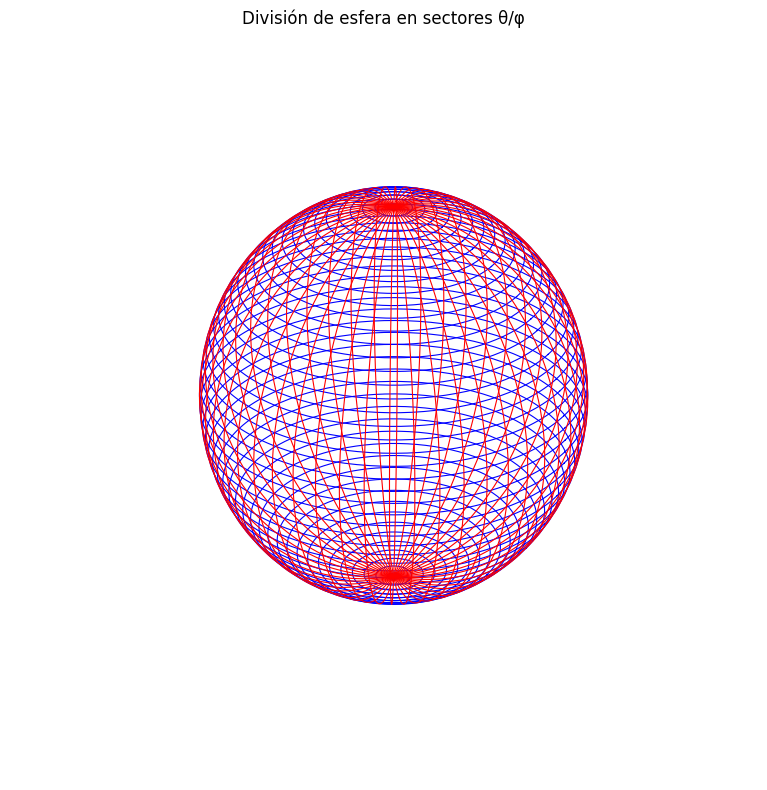

In [31]:
# Parámetros
radius = 0.005

# Crear figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar líneas horizontales (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Dibujar líneas verticales (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Estética
ax.set_box_aspect([1, 1, 1])
ax.set_title("División de esfera en sectores θ/φ")
ax.set_axis_off()
plt.tight_layout()
plt.show()


### Function to calculate the area of sectors of the mesh

In [32]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ):
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    delta_phi = np.abs(phi2 - phi1)
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

sectors.area = spherical_sector_area( sectors.theta_edges[:-1][:,None], sectors.theta_edges[1:][:,None], sectors.phi_edges[:-1][None,:], sectors.phi_edges[1:][None,:], radius=1., )

assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "El área total calculada no coincide con el área de la esfera."


### Plots the centers of each sector in the sphere mesh

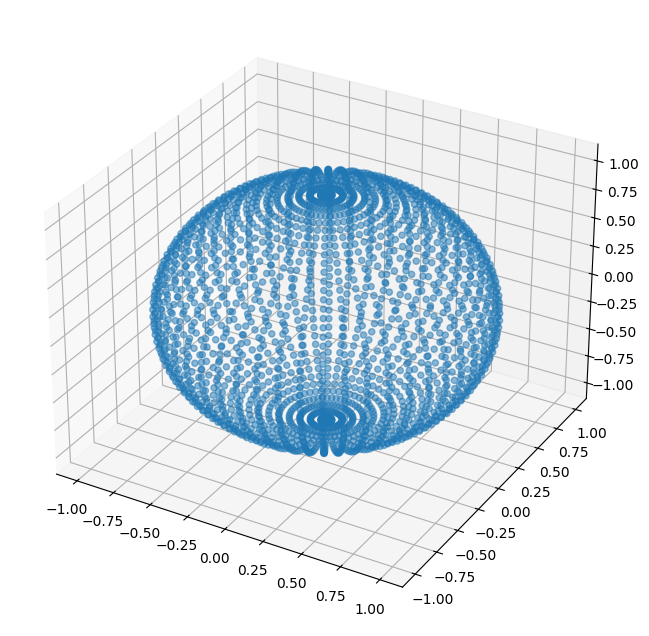

In [33]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

### Filters valid impacts

In [34]:
# Filtrar impactos físicos
hits = impact_df[impact_df['cs'] < 0]

# Validaciones básicas
assert hits['theta'].between(0., np.pi).all(), "theta fuera de rango"
assert hits['phi'].between(0., 2*np.pi).all(), "phi fuera de rango"


## Creates energy histogram in sphere

In [35]:
def hist(hits, sectors):
    # Histograma 2D con pesos
    hs_raw, _, _ = np.histogram2d(
        hits['theta'],
        hits['phi'],
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=np.abs(hits['cs'])
    )

    # Densidad por unidad de área
    hs = hs_raw / sectors.area

    # Validación de conservación
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(np.abs(hits['cs'])),
        atol=1e-4
    ), "La suma ponderada no coincide con la suma original de |cs|."

    # Normalización para visualización
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))

    # DataFrame final
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist


In [36]:
hits = df_impactos[df_impactos['cs'] < 0]   # impactos físicos


In [37]:
df_hist = hist(hits, sectors)

hs = df_hist['hs_density'].values

### Histogram graphic

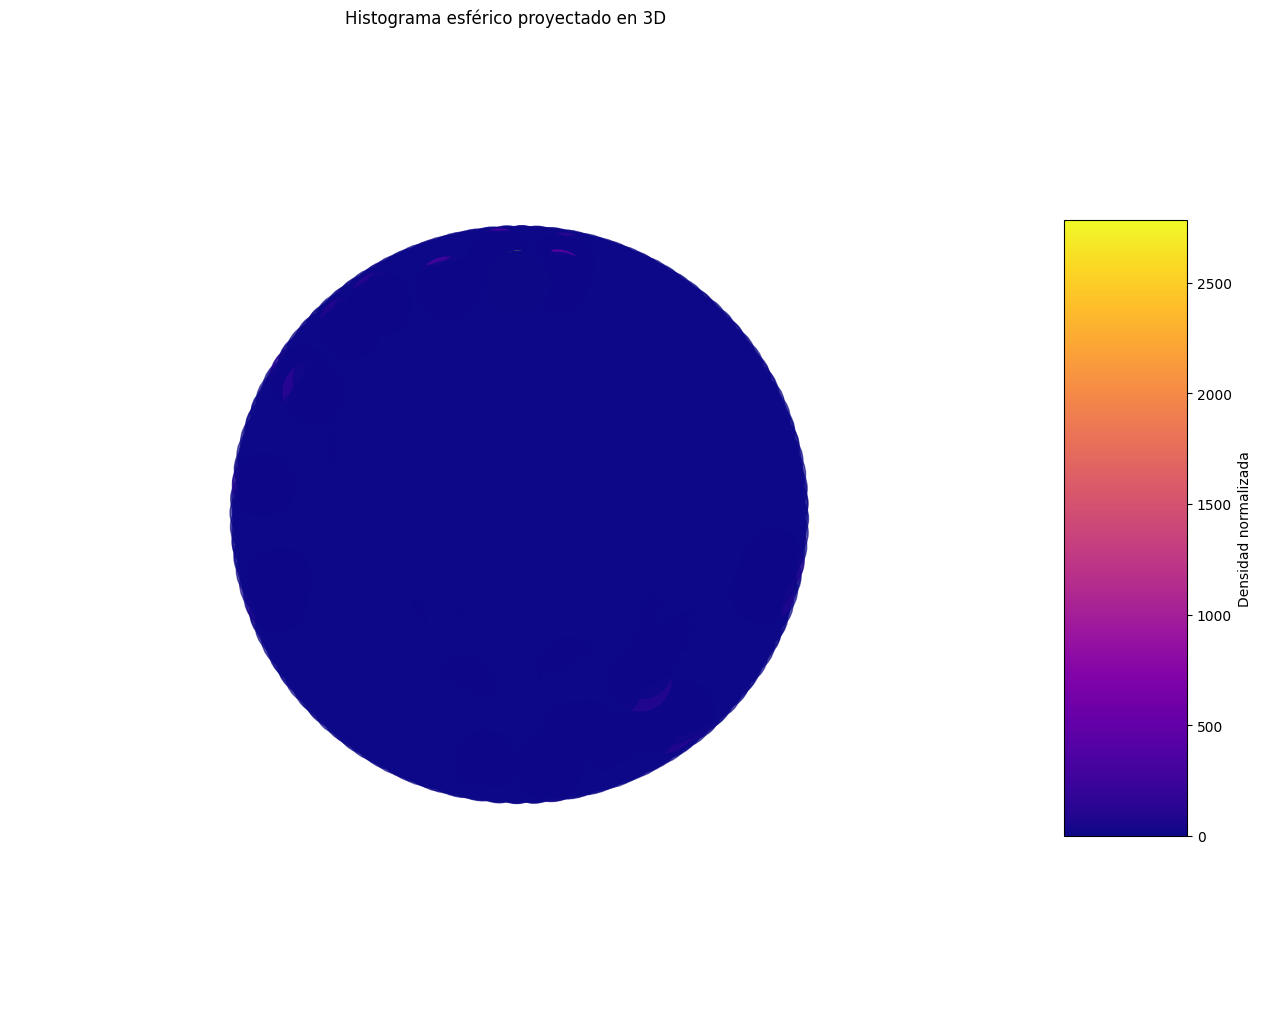

In [38]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Convertir centros de sector a coordenadas cartesianas
xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Aplanar para scatter
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs debe ser el histograma normalizado o densidad

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=2000)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Densidad normalizada")

ax.set_box_aspect([1, 1, 1])
ax.set_title("Histograma esférico proyectado en 3D")
ax.set_axis_off()

plt.show()


### Pyvista histogram graphic

In [39]:
def plot_histograma_esferico_pyvista(sectors, hs, radius=0.005, cmap="plasma"):
    
    # Convertir centros de sector a coordenadas cartesianas
    xs, ys, zs = sph_to_cart(radius, sectors.mtheta, sectors.mphi)

    # Aplanar para scatter
    X = xs.ravel()
    Y = ys.ravel()
    Z = zs.ravel()
    C = hs.ravel()

    # Crear nube de puntos
    point_cloud = pv.PolyData(np.column_stack([X, Y, Z]))
    point_cloud["densidad"] = C

    # Crear esfera del blanco
    sphere = pv.Sphere(radius=radius, center=(0, 0, 0))

    # Visualización
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter()

    # Esfera semitransparente
    plotter.add_mesh(sphere, color="lightblue", opacity=0.25)

    # Puntos coloreados por densidad
    plotter.add_points(
        point_cloud,
        scalars="densidad",
        render_points_as_spheres=True,
        point_size=20,
        cmap=cmap
    )

    plotter.add_scalar_bar(title="Densidad angular normalizada")
    plotter.show()

plot_histograma_esferico_pyvista(sectors, hs, radius=0.005, cmap="plasma")

Widget(value='<iframe src="http://localhost:65204/index.html?ui=P_0x218822228d0_2&reconnect=auto" class="pyvis…

## Import to rwhist file

In [40]:
import rwhist
rwhist.write(df_hist, filename="histograma_muestreo.h5")
